# 🌿 Cassava Leaf Disease Classification
## Notebook 01: Data Exploration and Analysis

**ML Coursework Project**

---

### Team Members
| Name | Registration Number | Contribution |
|------|---------------------|-------------|
| [Student 1 Name] | [Reg. Number] | 33.33% |
| [Student 2 Name] | [Reg. Number] | 33.33% |
| [Student 3 Name] | [Reg. Number] | 33.34% |

---

### Notebook Objectives
1. Load and explore the Cassava Leaf Disease dataset
2. Analyze class distribution
3. Visualize sample images from each class
4. Compute image statistics (dimensions, color distribution)
5. Identify potential challenges and preprocessing needs

## 1. Import Libraries

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

# Image processing
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm import tqdm

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Define Dataset Paths

In [2]:
# Define paths
BASE_PATH = Path('cassava-disease')
TRAIN_PATH = BASE_PATH / 'train' / 'train'
TEST_PATH = BASE_PATH / 'test' / 'test'
SUBMISSION_FILE = BASE_PATH / 'sample_submission_file.csv'

# Disease class descriptions
CLASS_DESCRIPTIONS = {
    'cbb': 'Cassava Bacterial Blight',
    'cbsd': 'Cassava Brown Streak Disease',
    'cgm': 'Cassava Green Mite',
    'cmd': 'Cassava Mosaic Disease',
    'healthy': 'Healthy Leaf'
}

# Verify paths exist
print(f"Base path exists: {BASE_PATH.exists()}")
print(f"Train path exists: {TRAIN_PATH.exists()}")
print(f"Test path exists: {TEST_PATH.exists()}")
print(f"Submission file exists: {SUBMISSION_FILE.exists()}")

Base path exists: True
Train path exists: True
Test path exists: True
Submission file exists: True


## 3. Explore Dataset Structure

In [3]:
# Get class folders in training data
class_folders = [f for f in os.listdir(TRAIN_PATH) if os.path.isdir(TRAIN_PATH / f)]
print(f"Found {len(class_folders)} classes: {class_folders}")

# Count images per class
class_counts = {}
for class_name in class_folders:
    class_path = TRAIN_PATH / class_name
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[class_name] = len(images)
    print(f"  {class_name}: {len(images)} images - {CLASS_DESCRIPTIONS.get(class_name, 'Unknown')}")

total_train = sum(class_counts.values())
print(f"\n📊 Total training images: {total_train}")

Found 5 classes: ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
  cbb: 466 images - Cassava Bacterial Blight
  cbsd: 1443 images - Cassava Brown Streak Disease
  cgm: 773 images - Cassava Green Mite
  cmd: 2658 images - Cassava Mosaic Disease
  healthy: 316 images - Healthy Leaf

📊 Total training images: 5656


In [4]:
# Count test images
test_images = [f for f in os.listdir(TEST_PATH) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"📊 Total test images: {len(test_images)}")

# Load submission file to check test labels
submission_df = pd.read_csv(SUBMISSION_FILE)
print(f"\nSubmission file shape: {submission_df.shape}")
print(submission_df.head())

📊 Total test images: 0

Submission file shape: (3774, 2)
  Category              Id
0     cbsd  test-img-0.jpg
1      cmd  test-img-1.jpg
2      cbb  test-img-2.jpg
3      cmd  test-img-3.jpg
4     cbsd  test-img-4.jpg


## 4. Class Distribution Analysis

In [5]:
# Create DataFrame for visualization
df_classes = pd.DataFrame({
    'Class': list(class_counts.keys()),
    'Count': list(class_counts.values()),
    'Description': [CLASS_DESCRIPTIONS.get(c, 'Unknown') for c in class_counts.keys()]
})
df_classes['Percentage'] = (df_classes['Count'] / df_classes['Count'].sum() * 100).round(2)
df_classes = df_classes.sort_values('Count', ascending=False)

print("📊 Training Data Class Distribution:")
print(df_classes.to_string(index=False))

📊 Training Data Class Distribution:
  Class  Count                  Description  Percentage
    cmd   2658       Cassava Mosaic Disease       46.99
   cbsd   1443 Cassava Brown Streak Disease       25.51
    cgm    773           Cassava Green Mite       13.67
    cbb    466     Cassava Bacterial Blight        8.24
healthy    316                 Healthy Leaf        5.59


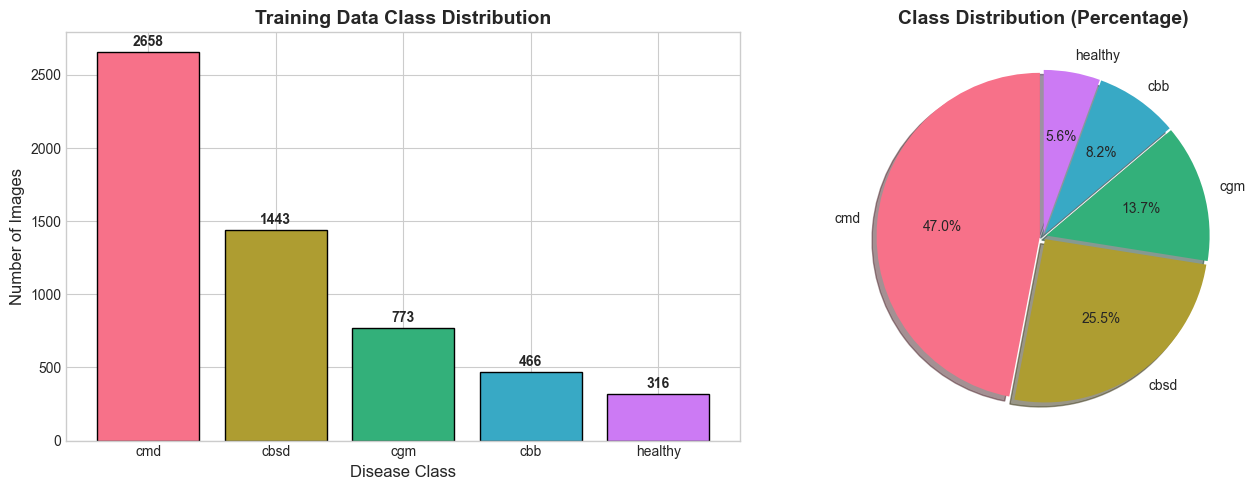

✅ Class distribution chart saved to outputs/class_distribution.png


In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('husl', len(df_classes))
bars = axes[0].bar(df_classes['Class'], df_classes['Count'], color=colors, edgecolor='black')
axes[0].set_xlabel('Disease Class', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Training Data Class Distribution', fontsize=14, fontweight='bold')

# Add count labels on bars
for bar, count in zip(bars, df_classes['Count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                 str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(df_classes['Count'], labels=df_classes['Class'], autopct='%1.1f%%', 
            colors=colors, explode=[0.02]*len(df_classes), shadow=True, startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Class distribution chart saved to outputs/class_distribution.png")

In [7]:
# Check class imbalance
max_count = df_classes['Count'].max()
min_count = df_classes['Count'].min()
imbalance_ratio = max_count / min_count

print(f"\n📊 Class Imbalance Analysis:")
print(f"  Maximum class size: {max_count} ({df_classes[df_classes['Count']==max_count]['Class'].values[0]})")
print(f"  Minimum class size: {min_count} ({df_classes[df_classes['Count']==min_count]['Class'].values[0]})")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 2:
    print("  ⚠️ Significant class imbalance detected! Consider using class weights or oversampling.")
else:
    print("  ✅ Classes are relatively balanced.")


📊 Class Imbalance Analysis:
  Maximum class size: 2658 (cmd)
  Minimum class size: 316 (healthy)
  Imbalance ratio: 8.41
  ⚠️ Significant class imbalance detected! Consider using class weights or oversampling.


## 5. Sample Images Visualization

In [8]:
def load_sample_images(class_name, n_samples=5):
    """Load sample images from a class folder."""
    class_path = TRAIN_PATH / class_name
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected = np.random.choice(image_files, min(n_samples, len(image_files)), replace=False)
    
    images = []
    for img_file in selected:
        img_path = class_path / img_file
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
    
    return images

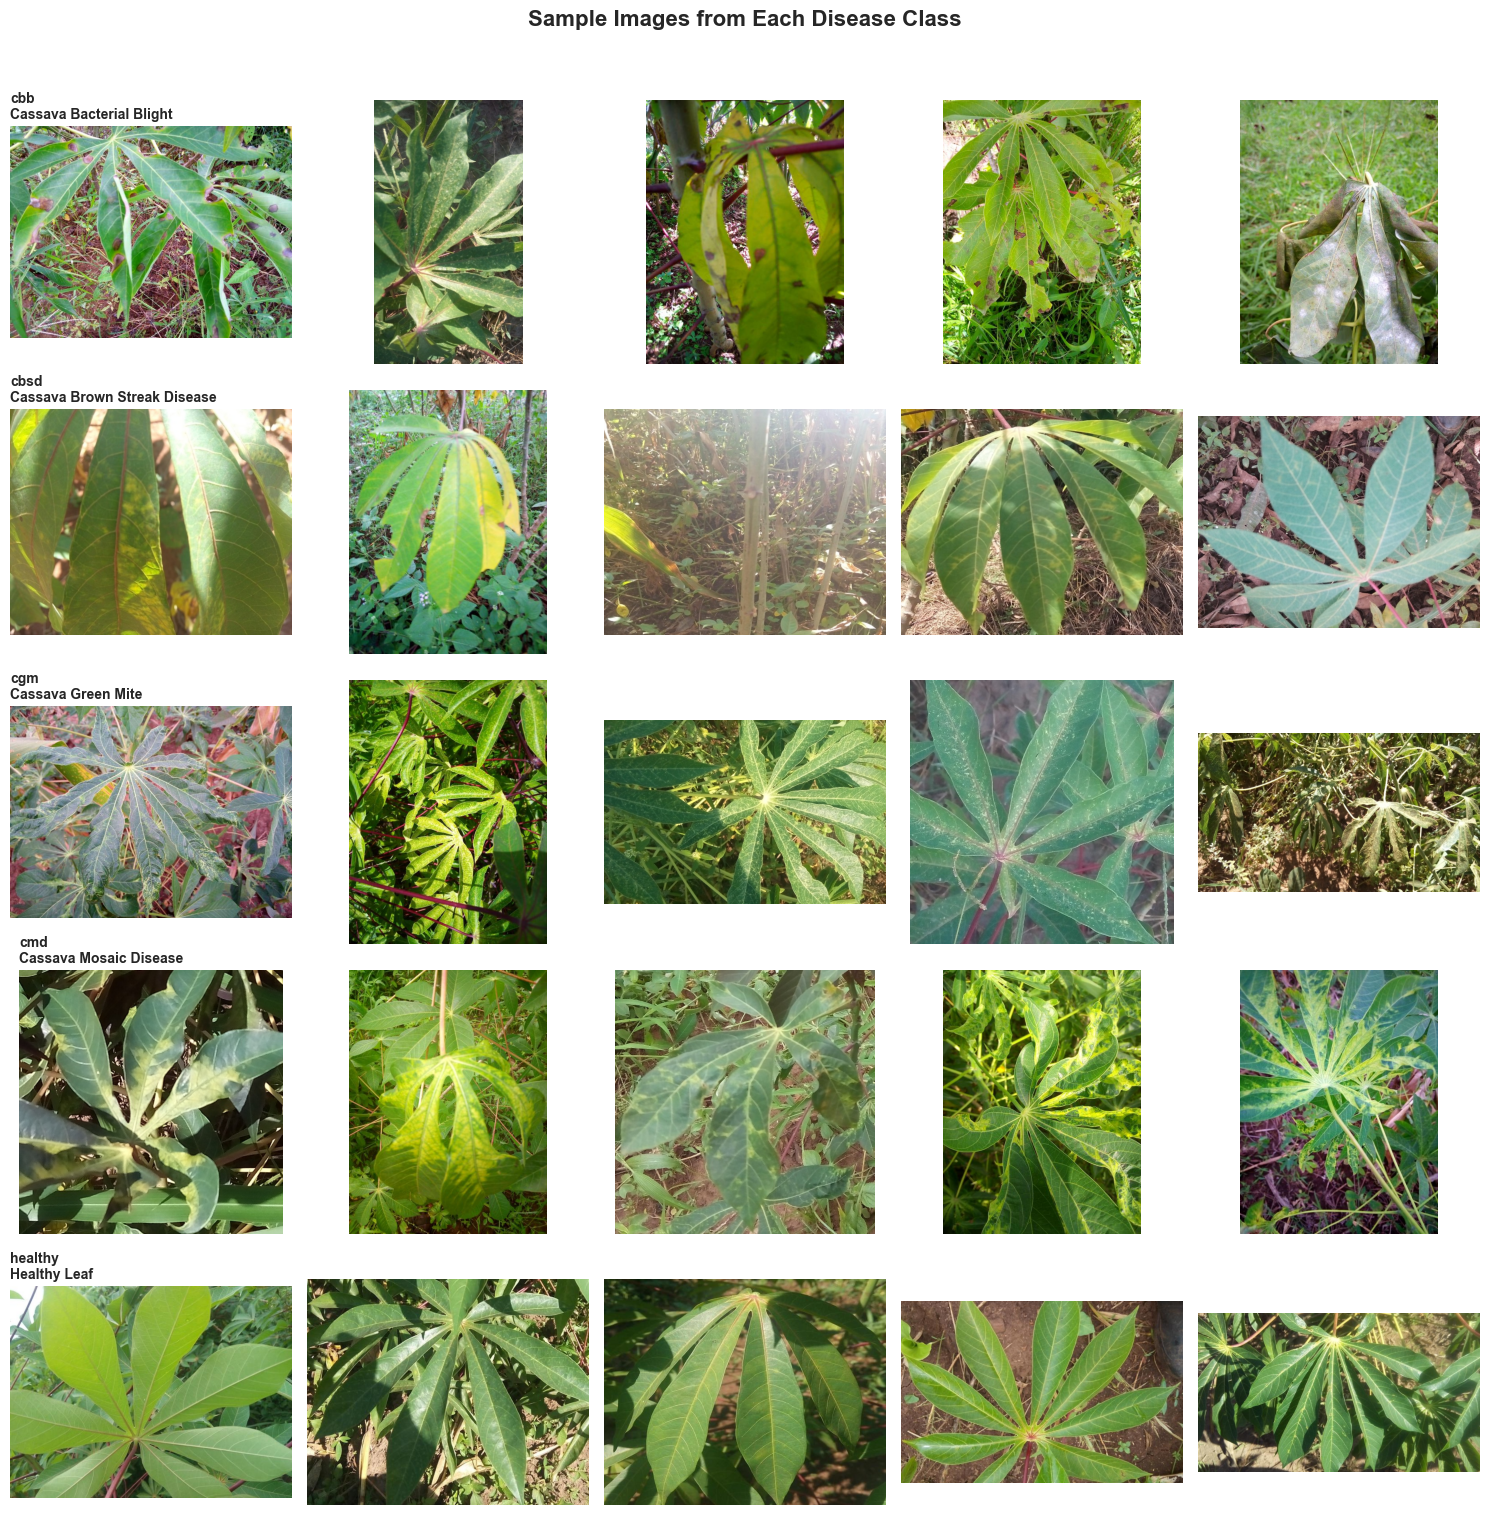

✅ Sample images grid saved to outputs/sample_images_grid.png


In [9]:
# Display sample images from each class
n_samples = 5
fig, axes = plt.subplots(len(class_folders), n_samples, figsize=(15, 3*len(class_folders)))

for i, class_name in enumerate(sorted(class_folders)):
    images = load_sample_images(class_name, n_samples)
    
    for j, img in enumerate(images):
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(f"{class_name}\n{CLASS_DESCRIPTIONS.get(class_name, '')}", 
                                  fontsize=10, fontweight='bold', loc='left')

plt.suptitle('Sample Images from Each Disease Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/sample_images_grid.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Sample images grid saved to outputs/sample_images_grid.png")

## 6. Image Dimension Analysis

In [10]:
# Analyze image dimensions across the dataset
def get_image_info(image_path):
    """Get image dimensions and file size."""
    img = Image.open(image_path)
    width, height = img.size
    file_size = os.path.getsize(image_path) / 1024  # KB
    return width, height, file_size

# Sample images for dimension analysis (analyze a subset for speed)
sample_size = 500  # Analyze 500 random images
all_image_paths = []

for class_name in class_folders:
    class_path = TRAIN_PATH / class_name
    images = [class_path / f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    all_image_paths.extend(images)

# Random sample
np.random.seed(42)
sampled_paths = np.random.choice(all_image_paths, min(sample_size, len(all_image_paths)), replace=False)

# Collect image info
widths, heights, file_sizes = [], [], []

print(f"Analyzing {len(sampled_paths)} images...")
for path in tqdm(sampled_paths):
    try:
        w, h, fs = get_image_info(path)
        widths.append(w)
        heights.append(h)
        file_sizes.append(fs)
    except Exception as e:
        continue

print(f"\n📊 Image Dimension Statistics (n={len(widths)}):")
print(f"  Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}, Std: {np.std(widths):.0f}")
print(f"  Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}, Std: {np.std(heights):.0f}")
print(f"  File Size (KB) - Min: {min(file_sizes):.1f}, Max: {max(file_sizes):.1f}, Mean: {np.mean(file_sizes):.1f}")

Analyzing 500 images...


100%|██████████| 500/500 [00:00<00:00, 842.66it/s]


📊 Image Dimension Statistics (n=500):
  Width  - Min: 456, Max: 1196, Mean: 614, Std: 142
  Height - Min: 500, Max: 1027, Mean: 568, Std: 108
  File Size (KB) - Min: 31.4, Max: 367.1, Mean: 141.7


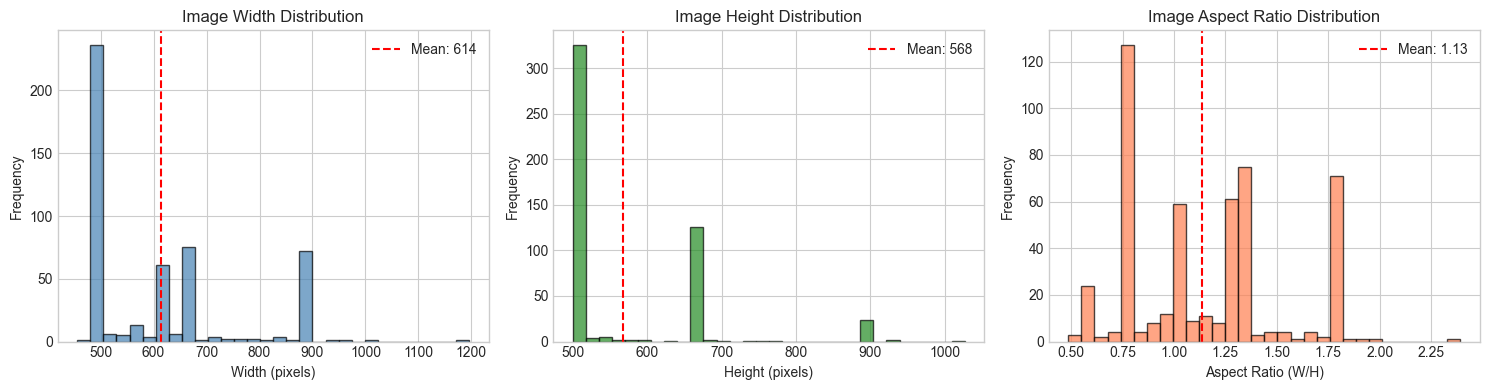

✅ Image dimension analysis saved to outputs/image_dimensions.png


In [11]:
# Visualize dimension distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Width distribution
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Image Width Distribution')
axes[0].legend()

# Height distribution
axes[1].hist(heights, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Image Height Distribution')
axes[1].legend()

# Aspect ratio
aspect_ratios = [w/h for w, h in zip(widths, heights)]
axes[2].hist(aspect_ratios, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[2].axvline(np.mean(aspect_ratios), color='red', linestyle='--', label=f'Mean: {np.mean(aspect_ratios):.2f}')
axes[2].set_xlabel('Aspect Ratio (W/H)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Image Aspect Ratio Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/image_dimensions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Image dimension analysis saved to outputs/image_dimensions.png")

## 7. Color Distribution Analysis

In [12]:
def compute_color_histogram(image_path):
    """Compute RGB color histogram for an image."""
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Compute histogram for each channel
    hist_r = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    hist_g = cv2.calcHist([img], [1], None, [256], [0, 256]).flatten()
    hist_b = cv2.calcHist([img], [2], None, [256], [0, 256]).flatten()
    
    return hist_r, hist_g, hist_b

# Compute average color histogram per class
class_color_histograms = {}

print("Computing color histograms per class...")
for class_name in tqdm(class_folders):
    class_path = TRAIN_PATH / class_name
    images = [class_path / f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Sample 50 images per class
    sampled = np.random.choice(images, min(50, len(images)), replace=False)
    
    hist_r_avg = np.zeros(256)
    hist_g_avg = np.zeros(256)
    hist_b_avg = np.zeros(256)
    
    for img_path in sampled:
        try:
            hr, hg, hb = compute_color_histogram(img_path)
            hist_r_avg += hr
            hist_g_avg += hg
            hist_b_avg += hb
        except:
            continue
    
    # Normalize
    hist_r_avg /= len(sampled)
    hist_g_avg /= len(sampled)
    hist_b_avg /= len(sampled)
    
    class_color_histograms[class_name] = (hist_r_avg, hist_g_avg, hist_b_avg)

Computing color histograms per class...


100%|██████████| 5/5 [00:00<00:00,  5.69it/s]


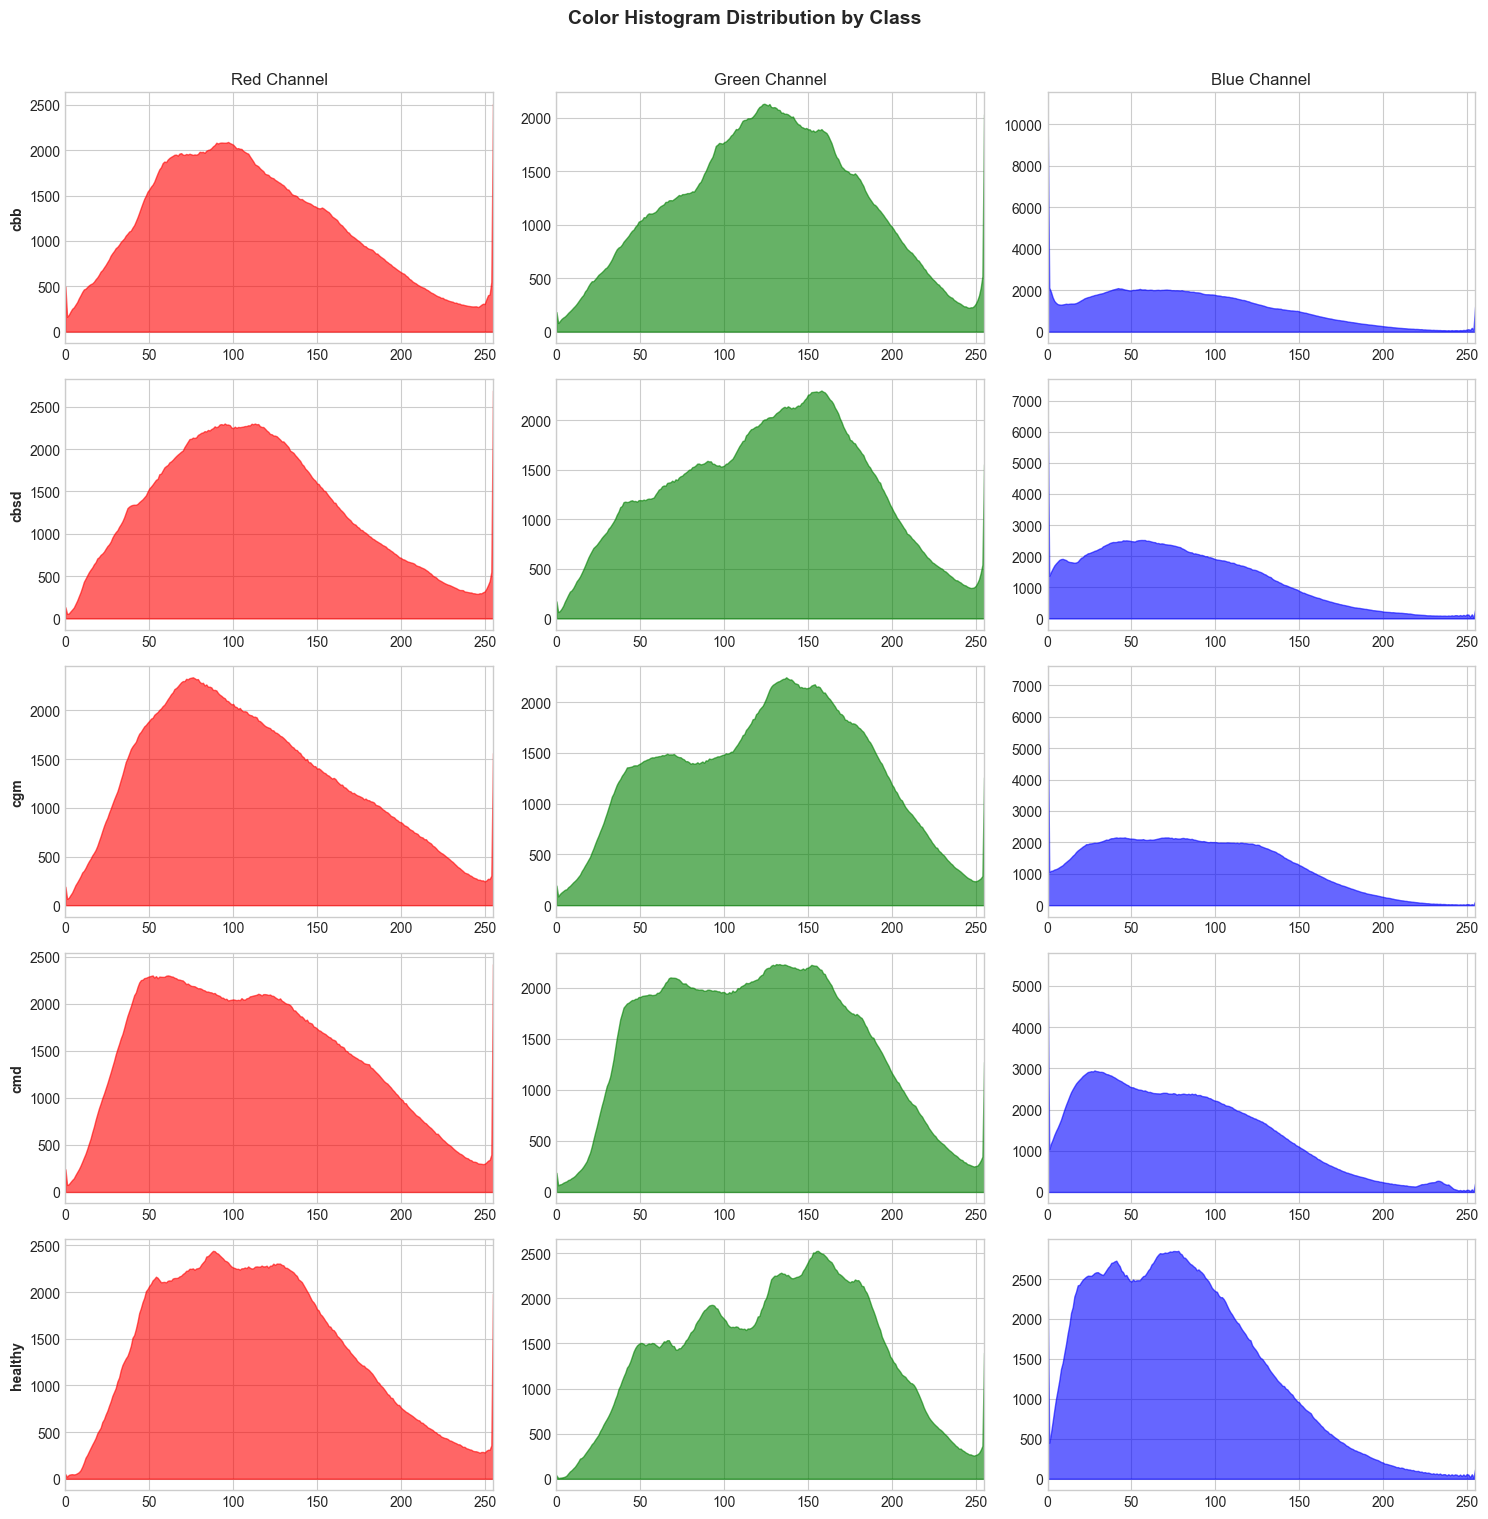

✅ Color histogram analysis saved to outputs/color_histograms.png


In [13]:
# Visualize color histograms per class
fig, axes = plt.subplots(len(class_folders), 3, figsize=(15, 3*len(class_folders)))

for i, class_name in enumerate(sorted(class_folders)):
    hist_r, hist_g, hist_b = class_color_histograms[class_name]
    
    axes[i, 0].fill_between(range(256), hist_r, color='red', alpha=0.6)
    axes[i, 0].set_ylabel(class_name, fontsize=10, fontweight='bold')
    axes[i, 0].set_xlim(0, 255)
    if i == 0:
        axes[i, 0].set_title('Red Channel', fontsize=12)
    
    axes[i, 1].fill_between(range(256), hist_g, color='green', alpha=0.6)
    axes[i, 1].set_xlim(0, 255)
    if i == 0:
        axes[i, 1].set_title('Green Channel', fontsize=12)
    
    axes[i, 2].fill_between(range(256), hist_b, color='blue', alpha=0.6)
    axes[i, 2].set_xlim(0, 255)
    if i == 0:
        axes[i, 2].set_title('Blue Channel', fontsize=12)

plt.suptitle('Color Histogram Distribution by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/color_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Color histogram analysis saved to outputs/color_histograms.png")

## 8. Mean Image per Class

In [14]:
def compute_mean_image(class_name, target_size=(224, 224), n_samples=100):
    """Compute the mean image for a class."""
    class_path = TRAIN_PATH / class_name
    images = [class_path / f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    sampled = np.random.choice(images, min(n_samples, len(images)), replace=False)
    
    mean_img = np.zeros((target_size[0], target_size[1], 3), dtype=np.float32)
    
    for img_path in sampled:
        try:
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, target_size)
            mean_img += img.astype(np.float32)
        except:
            continue
    
    mean_img /= len(sampled)
    return mean_img.astype(np.uint8)

# Compute mean images
print("Computing mean images per class...")
mean_images = {}
for class_name in tqdm(class_folders):
    mean_images[class_name] = compute_mean_image(class_name)

Computing mean images per class...


100%|██████████| 5/5 [00:01<00:00,  3.43it/s]


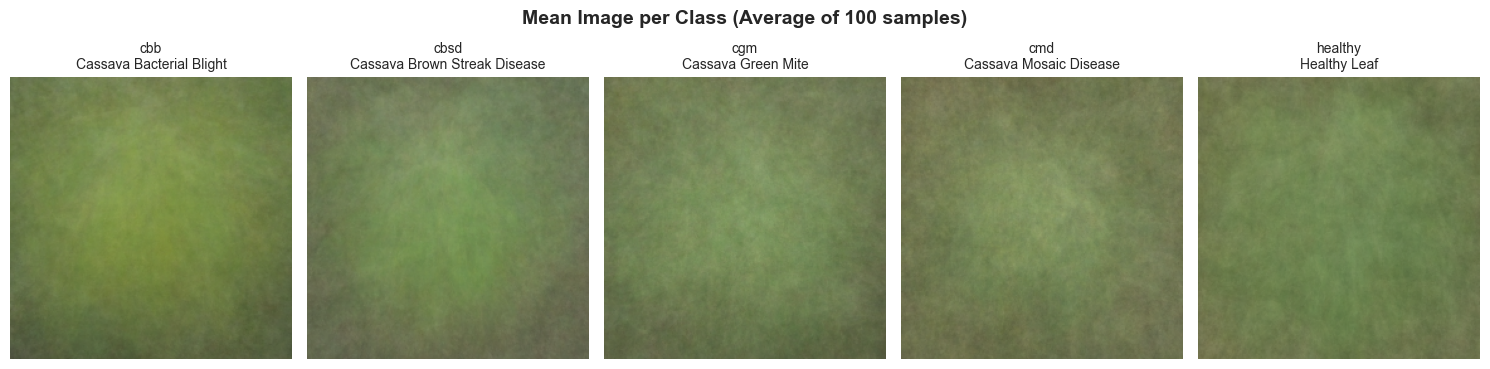

✅ Mean images saved to outputs/mean_images.png


In [15]:
# Visualize mean images
fig, axes = plt.subplots(1, len(class_folders), figsize=(15, 4))

for i, class_name in enumerate(sorted(class_folders)):
    axes[i].imshow(mean_images[class_name])
    axes[i].set_title(f"{class_name}\n{CLASS_DESCRIPTIONS.get(class_name, '')}", fontsize=10)
    axes[i].axis('off')

plt.suptitle('Mean Image per Class (Average of 100 samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/mean_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Mean images saved to outputs/mean_images.png")

## 9. Key Findings Summary

In [16]:
# Summary statistics
print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)

print(f"\n🔹 Dataset Overview:")
print(f"   - Total training images: {total_train:,}")
print(f"   - Total test images: {len(test_images):,}")
print(f"   - Number of classes: {len(class_folders)}")

print(f"\n🔹 Class Distribution:")
for _, row in df_classes.iterrows():
    print(f"   - {row['Class']}: {row['Count']:,} images ({row['Percentage']}%)")

print(f"\n🔹 Class Imbalance:")
print(f"   - Imbalance ratio: {imbalance_ratio:.2f}")
print(f"   - {'⚠️ Class weights recommended' if imbalance_ratio > 2 else '✅ Relatively balanced'}")

print(f"\n🔹 Image Dimensions:")
print(f"   - Mean size: {np.mean(widths):.0f} x {np.mean(heights):.0f} pixels")
print(f"   - Will resize to: 224 x 224 (for transfer learning)")

print(f"\n🔹 Preprocessing Recommendations:")
print(f"   1. Resize images to 224x224 for pre-trained models")
print(f"   2. Apply data augmentation (rotation, flip, zoom)")
print(f"   3. Normalize using ImageNet mean/std")
if imbalance_ratio > 2:
    print(f"   4. Use class weights to handle imbalance")

print("\n" + "="*60)

📊 EXPLORATORY DATA ANALYSIS SUMMARY

🔹 Dataset Overview:
   - Total training images: 5,656
   - Total test images: 0
   - Number of classes: 5

🔹 Class Distribution:
   - cmd: 2,658 images (46.99%)
   - cbsd: 1,443 images (25.51%)
   - cgm: 773 images (13.67%)
   - cbb: 466 images (8.24%)
   - healthy: 316 images (5.59%)

🔹 Class Imbalance:
   - Imbalance ratio: 8.41
   - ⚠️ Class weights recommended

🔹 Image Dimensions:
   - Mean size: 614 x 568 pixels
   - Will resize to: 224 x 224 (for transfer learning)

🔹 Preprocessing Recommendations:
   1. Resize images to 224x224 for pre-trained models
   2. Apply data augmentation (rotation, flip, zoom)
   3. Normalize using ImageNet mean/std
   4. Use class weights to handle imbalance



In [17]:
# Save summary to file
summary_data = {
    'total_train_images': total_train,
    'total_test_images': len(test_images),
    'num_classes': len(class_folders),
    'class_counts': class_counts,
    'imbalance_ratio': imbalance_ratio,
    'mean_width': np.mean(widths),
    'mean_height': np.mean(heights)
}

import json
os.makedirs('outputs', exist_ok=True)
with open('outputs/eda_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=2)

print("✅ EDA summary saved to outputs/eda_summary.json")

✅ EDA summary saved to outputs/eda_summary.json


---
## 📌 Next Steps

Proceed to **Notebook 02: Data Preprocessing** to:
1. Create data loading pipeline
2. Apply preprocessing and augmentation
3. Prepare data for model training

---
*End of Notebook 01*